<a href="https://colab.research.google.com/github/okayhozay/AI-ML-and-Deep-Learning/blob/main/AI-ML-and-Deep-Learning%20/Projects/Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

In [ ]:
!export KAGGLE_API_TOKEN=KGAT_858579649f1d304736ce621966588a01

In [ ]:
!kaggle datasets download \
  -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 224MB/s]



In [ ]:
!unzip -q \
  /content/chest-xray-pneumonia.zip \
  -d /content/chest_xray_data

In [ ]:
random.seed(42)
np.random.seed(45)
tf.random.set_seed(45)

In [ ]:
dataset_path = '/content/chest_xray_data/chest_xray'

In [ ]:
import os

In [ ]:
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

In [ ]:
def count_images(directory):
  counts = {}

  for class_name in os.listdir(directory):
    class_path = os.path.join(directory, class_name)

    if os.path.isdir(class_path):
      counts[class_name] = len([
          file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(
          (".jpg", ".jpeg", ".png"))
        ])
  return counts


print("Training images:", count_images(train_dir))
print("Testing images:", count_images(test_dir))

Training images: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Testing images: {'PNEUMONIA': 390, 'NORMAL': 234}


In [ ]:
image_height = 128
image_width = 128
image_size = (image_height, image_width)
batch_size = 22
epochs = 550
class_name = ['NORMAL', 'PNEUMONIA']

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, labels = 'inferred', label_mode = 'binary', class_names = class_name, color_mode = 'grayscale', image_size = image_size, batch_size = batch_size, shuffle = True, seed = 45, validation_split = 0.2, subset = 'training')

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [ ]:
validation_ds = tf.keras.utils.image_dataset_from_directory(train_dir, labels = 'inferred', label_mode = 'binary', class_names = class_name, color_mode = 'grayscale', image_size = image_size, batch_size = batch_size, shuffle = True, seed = 45, validation_split = 0.2, subset = 'validation')

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, labels = 'inferred', label_mode = 'binary', class_names = class_name, color_mode = 'grayscale', image_size = image_size, batch_size = batch_size, shuffle = True)

Found 624 files belonging to 2 classes.


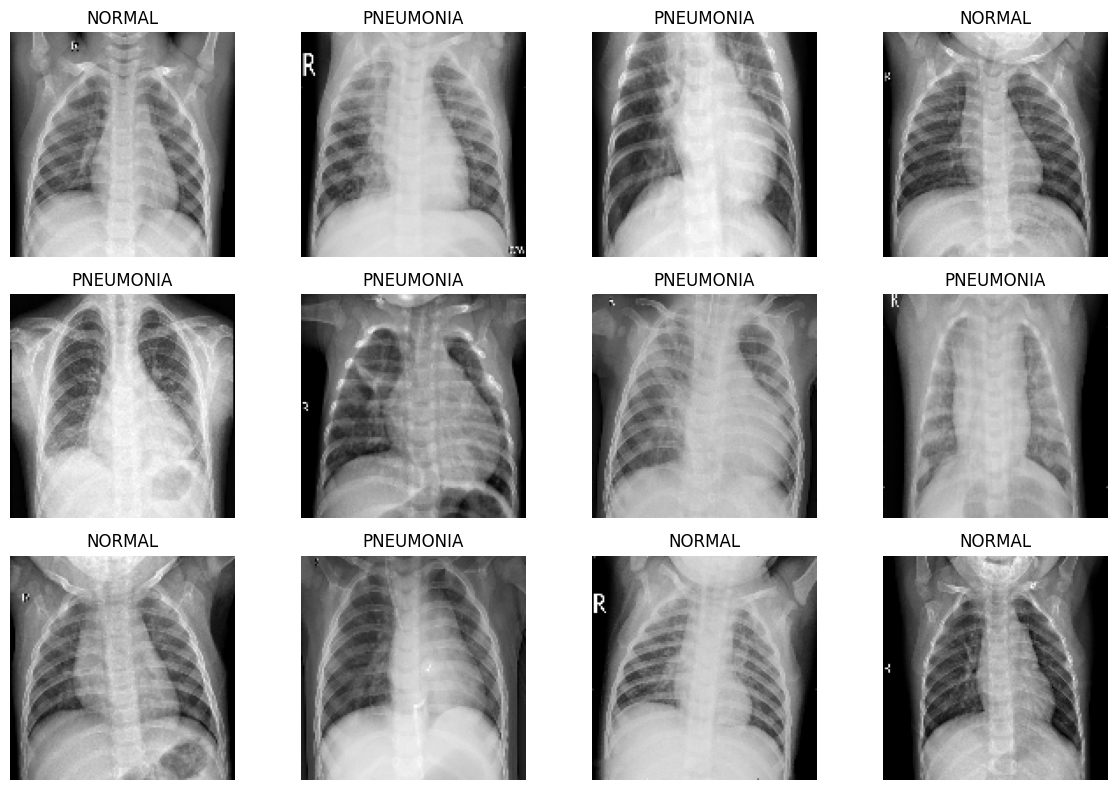

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
  for index in range(12):
    plt.subplot(3, 4, index + 1)

    plt.imshow(
      images[index].numpy().squeeze(),
      cmap="gray")

    label = int(labels[index].numpy()[0])

    plt.title(class_name[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def get_callbacks(model_name):
  return[callbacks.EarlyStopping(monitor = 'val_loss', patience = 4, restore_best_weights = True , verbose = 1),
         callbacks.ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 2, min_lr = 1e-6, verbose = 1),
         callbacks.ModelCheckpoint(filepath = f'/content/{model_name}.keras')]

In [ ]:
image_counts = count_images(train_dir)
normal_count = image_counts['NORMAL']
pneumonia_count = image_counts['PNEUMONIA']
total_count = normal_count + pneumonia_count

In [ ]:
class_weight = {0: total_count/(2*normal_count), 1: total_count / (2 * pneumonia_count)}

In [ ]:
ann_model = models.Sequential([layers.Input(shape = (image_height, image_width, 1)),
                               layers.Rescaling(1.0 / 255),
                               layers.Flatten(),
                               layers.Dense(256, activation = 'relu'),
                               layers.BatchNormalization(),
                               layers.Dropout(0.5),
                               layers.Dense(128, activation = 'relu'),
                               layers.Dropout(0.3),
                               layers.Dense(1, activation = 'sigmoid')
                               ])

In [ ]:
ann_model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics = ['accuracy', keras.metrics.Precision(name = 'precision'), keras.metrics.Recall(name = 'recall'), keras.metrics.AUC(name = 'auc')])

In [ ]:
ann_model.fit(train_ds, validation_data = validation_ds, epochs = epochs, class_weight = class_weight, callbacks = get_callbacks('ann_pneumonia'))

Epoch 1/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 38s 186ms/step - accuracy: 0.8658 - auc: 0.9458 - loss: 0.3004 - precision: 0.9596 - recall: 0.8559 - val_accuracy: 0.8706 - val_auc: 0.9817 - val_loss: 0.2953 - val_precision: 0.9922 - val_recall: 0.8305 - learning_rate: 0.0010
Epoch 2/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 187ms/step - accuracy: 0.9283 - auc: 0.9750 - loss: 0.1979 - precision: 0.9731 - recall: 0.9295 - val_accuracy: 0.8389 - val_auc: 0.9798 - val_loss: 0.3578 - val_precision: 0.8210 - val_recall: 0.9987 - learning_rate: 0.0010
Epoch 3/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 34s 179ms/step - accuracy: 0.9283 - auc: 0.9769 - loss: 0.1900 - precision: 0.9776 - recall: 0.9250 - val_accuracy: 0.9559 - val_auc: 0.9864 - val_loss: 0.1287 - val_precision: 0.9676 - val_recall: 0.9726 - learning_rate: 0.0010
Epoch 4/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9317 - auc: 0.9807 - loss: 0.1758 - precision: 0.9748 - recall: 0.9324 - val_accuracy: 0.8025 - val_auc: 0.9732 - val_lo

In [ ]:
#CNN

In [ ]:
data_augmentation = models.Sequential([layers.RandomRotation(0.03), layers.RandomZoom(0.08), layers.RandomTranslation(height_factor = 0.05, width_factor = 0.05), layers.RandomContrast(0.10)])

In [ ]:
cnn_model = models.Sequential([layers.Input(shape = (image_height, image_width, 1)),
                               data_augmentation,
                               layers.Rescaling(1.0/255),
                               layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
                               layers.BatchNormalization(),
                               layers.MaxPooling2D((2, 2)),
                               layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
                               layers.BatchNormalization(),
                               layers.MaxPooling2D((2, 2)),
                               layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'),
                               layers.BatchNormalization(),
                               layers.MaxPooling2D((2, 2)),
                               layers.GlobalAveragePooling2D(),
                               layers.Dense(128, activation = 'relu'),
                               layers.Dropout(0.5),
                               layers.Dense(1, activation = 'sigmoid')
                               ])

In [ ]:
cnn_model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001),
                  loss = 'binary_crossentropy',
                  metrics = ['accuracy', keras.metrics.Precision(name = 'Precision'),
                             keras.metrics.Recall(name = 'Recall'),
                             keras.metrics.AUC(name = 'AUC')
                             ])

In [ ]:
cnn_model.fit(train_ds, validation_data = validation_ds,
              epochs = epochs, class_weight = class_weight,
              callbacks = get_callbacks('cnn_pneumonia'))

Epoch 1/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 624s 3s/step - AUC: 0.9259 - Precision: 0.9602 - Recall: 0.8308 - accuracy: 0.8483 - loss: 0.3417 - val_AUC: 0.5000 - val_Precision: 0.7354 - val_Recall: 1.0000 - val_accuracy: 0.7354 - val_loss: 1.9163 - learning_rate: 0.0010
Epoch 2/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 700s 4s/step - AUC: 0.9553 - Precision: 0.9695 - Recall: 0.8684 - accuracy: 0.8816 - loss: 0.2673 - val_AUC: 0.5000 - val_Precision: 0.7354 - val_Recall: 1.0000 - val_accuracy: 0.7354 - val_loss: 6.1954 - learning_rate: 0.0010
Epoch 3/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - AUC: 0.9694 - Precision: 0.9759 - Recall: 0.8977 - accuracy: 0.9073 - loss: 0.2195 - val_AUC: 0.9617 - val_Precision: 0.7942 - val_Recall: 0.9961 - val_accuracy: 0.8073 - val_loss: 0.4465 - learning_rate: 0.0010
Epoch 4/550
190/190 ━━━━━━━━━━━━━━━━━━━━ 614s 3s/step - AUC: 0.9728 - Precision: 0.9757 - Recall: 0.9044 - accuracy: 0.9121 - loss: 0.2057 - val_AUC: 0.5809 - val_Precision: 0.7354 - val_Recall: 1

In [ ]:
lstm_model = models.Sequential([layers.Input(shape = (image_height, image_width ,1)),
                                layers.Rescaling(1.0/255),
                                layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
                                layers.Reshape((image_height, image_width)),
                                layers.Bidirectional(layers.LSTM(64, return_sequences = True)),
                                layers.Dropout(0.3),
                                layers.Bidirectional(layers.LSTM(32)),
                                layers.Dense(64, activation = 'relu'),
                                layers.Dropout(0.3),
                                layers.Dense(1, activation = 'sigmoid')
                                ])

In [ ]:
lstm_model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001),
                   loss = 'binary_crossentropy',
                   metrics = ['accuracy', keras.metrics.Precision(name = 'Precision'), keras.metrics.Recall(name = 'Recall'),
                              keras.metrics.AUC(name = 'AUC')])

In [ ]:
lstm_model.fit(train_ds, validation_data = validation_ds, epochs = epochs, class_weight = class_weight,
               callbacks = get_callbacks('lstm_pneumonia'))

In [ ]:
cnn_model.save('cnn.keras')
lstm_model.save('lstm.keras')
ann_model.save('ann.keras')